## Part 1: Wikidata Editor Network Analysis

### Task A: Data Processing and Network Construction

In the network modeling phase, the definition of nodes and edge connection rules is fundamental to the validity of the subsequent topological analysis. To transform structured tabular data into a representation of social interaction, this study adopts a **co-occurrence network modeling approach**. A co-occurrence network links entities based on their shared presence within a specific context. This method is highly effective for implicit community detection because it captures the shared focus of participants. 

Data processing is executed by identifying unique discussion contexts. Instead of creating a complex system to map user names to integer IDs, the `page_name` and `thread_subject` are concatenated to create a single identifier. Python's `itertools.combinations` is subsequently employed to generate undirected edges between all users in the same group.

In [4]:
# Import requisite analytical and visualization libraries
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random
from itertools import combinations

# Suppress non-critical execution warnings to maintain output clarity
import warnings
warnings.filterwarnings('ignore')

# Set global random seed for reproducible results
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Network Construction Function (Task A)
def build_wikidata_network(file_path):
    """Reads CSV data and constructs a Wikidata editor co-occurrence network."""
    
    # Data Ingestion: Load dataset and filter missing essential identifiers
    df = pd.read_csv(file_path)
    df = df.dropna(subset=['page_name', 'thread_subject', 'username'])

    # Context Definition: Concatenate page and thread to form a unique discussion context ID
    df['context_id'] = df['page_name'].astype(str) + " | " + df['thread_subject'].astype(str)

    # Grouping: Extract unique sets of editors participating within each specific context
    grouped_users = df.groupby('context_id')['username'].apply(set).tolist()

    # Edge Generation: Establish undirected edges between all users co-occurring in the same group
    edges = []
    for users in grouped_users:
        if len(users) > 1:
            edges.extend(list(combinations(users, 2)))

    # Graph Construction: Instantiate the network and populate topological edges
    G = nx.Graph()
    G.add_edges_from(edges)

    # Output Task A responses
    print("\n=== Task A: Network Construction ===")
    print(f"Dataset: {file_path}")
    print(f"Number of nodes (editors): {G.number_of_nodes()}")
    print(f"Number of edges (conversations): {G.number_of_edges()}")
    print("\n1. Nodes and edges representation:")
    print("   - Nodes: Wikidata editors (users who made comments).")
    print("   - Edges: Two editors are connected if they both commented in the same page and the same thread.")
    print("2. Data structure:")
    print("   - I used a NetworkX Graph object (undirected).")
    print("3. Additional information:")
    print("   - Additional info (e.g., number of comments) could be stored as node/edge attributes.")
    print("4. Algorithmic approach:")
    print("   - Step 1: Load CSV and remove missing values.")
    print("   - Step 2: Create a composite key (page_name|thread_subject) to identify a discussion context.")
    print("   - Step 3: Group users by this key, then generate all pairs of users in each group.")
    print("   - Step 4: Add edges to the graph using NetworkX.")

    return G

### Task B: Topological Metrics and Small-World Characterization

To evaluate the structural features of the Wikidata networks, it is essential to calculate key topological metrics: the Largest Connected Component (LCC), the average clustering coefficient (C), and the average shortest path length (L). To determine if the observed structures are significant, the empirical results are benchmarked against an Erdős-Rényi (ER) random graph model of equivalent size.

For the large-scale network, calculating the exact all-pairs shortest paths presents a severe computational bottleneck (O(|V|^3)). To resolve this, a node sampling approximation algorithm is implemented, selecting a subset of representative nodes within the LCC to efficiently estimate the global characteristic path length. The degree distribution is also visualized to confirm the presence of right-skewed, scale-free properties dominated by "Hub" editors.

In [5]:
# Topological Metrics and Comparative Analysis Function (Task B)
def analyze_network_metrics(G):
    """Calculates structural metrics and benchmarks against an Erdős-Rényi random graph."""
    print("\n=== Task B: Network Metrics ===")

    # Fundamental Statistics: Compute total nodes, edges, and average degree
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    degrees = [d for n, d in G.degree()]
    avg_degree = sum(degrees) / num_nodes
    print(f"Number of nodes: {num_nodes}")
    print(f"Number of edges: {num_edges}")
    print(f"Average degree: {avg_degree:.4f}")

    # Component Extraction: Isolate the Largest Connected Component (LCC) for path analysis
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    LCC = G.subgraph(components[0])
    print(f"Largest connected component (LCC) contains {LCC.number_of_nodes()} nodes ({LCC.number_of_nodes()/num_nodes:.2%})")

    # Empirical Metrics: Calculate actual average clustering coefficient and shortest path length
    C_real = nx.average_clustering(G)
    L_real = nx.average_shortest_path_length(LCC)
    print(f"Average clustering coefficient (C): {C_real:.4f}")
    print(f"Average shortest path length (L): {L_real:.4f}")

    # Baseline Comparison: Generate an equivalent Erdős-Rényi (ER) random graph
    p = (2 * num_edges) / (num_nodes * (num_nodes - 1))
    G_rand = nx.erdos_renyi_graph(num_nodes, p, seed=SEED)

    # Random Graph Metrics: Extract LCC and compute baseline metrics for the ER model
    rand_comp = sorted(nx.connected_components(G_rand), key=len, reverse=True)
    LCC_rand = G_rand.subgraph(rand_comp[0])
    C_rand = nx.average_clustering(G_rand)
    L_rand = nx.average_shortest_path_length(LCC_rand)
    print(f"\nRandom network (Erdos-Renyi) with same size:")
    print(f"p = {p:.6f}")
    print(f"C_rand = {C_rand:.6f}")
    print(f"L_rand = {L_rand:.4f}")

    # Topological Interpretation: Determine small-world properties based on structural comparisons
    print("\n=== Interpretation ===")
    print(f"Real network: C = {C_real:.4f}, L = {L_real:.4f}")
    print(f"Random network: C = {C_rand:.4f}, L = {L_rand:.4f}")
    if C_real > C_rand and L_real <= L_rand:
        print("→ The network is a **small-world network** (high clustering, short paths).")
        print("This means editors form tight local groups but can still reach each other quickly through short chains of conversation.")
    elif C_real > C_rand and L_real > L_rand:
        print("→ The network is **more regular** than random.")
    else:
        print("→ The network is close to a **random network**.")

    # Visualization: Plot the degree distribution to evaluate scale-free characteristics
    plt.figure(figsize=(8,5))
    plt.hist(degrees, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    plt.title("Degree Distribution of Wikidata Editor Network")
    plt.xlabel("Degree (number of connections)")
    plt.ylabel("Frequency")
    plt.grid(axis='y', alpha=0.5)
    plt.show()

# Approximation Analysis Function for Large-Scale Networks
def analyze_large_network_approx(G, sample_size=100):
    """Executes topological analysis using node sampling to mitigate computational bottlenecks."""
    print("\n=== Task B: Network Metrics (Approximation for Large Network) ===")

    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    degrees = [d for n, d in G.degree()]
    avg_degree = sum(degrees) / num_nodes
    print(f"Number of nodes: {num_nodes}")
    print(f"Number of edges: {num_edges}")
    print(f"Average degree: {avg_degree:.4f}")

    # Isolate the LCC
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    LCC = G.subgraph(components[0])
    print(f"LCC contains {LCC.number_of_nodes()} nodes ({LCC.number_of_nodes()/num_nodes:.2%})")

    # Calculate global clustering coefficient
    C_real = nx.average_clustering(G)
    print(f"Average clustering coefficient (C): {C_real:.4f}")

    # Path Length Approximation: Calculate single-source shortest paths for a random sample
    sample_nodes = random.sample(list(LCC.nodes()), min(sample_size, LCC.number_of_nodes()))
    total_path_length = 0
    total_pairs = 0
    for source in sample_nodes:
        lengths = nx.single_source_shortest_path_length(LCC, source)
        total_path_length += sum(lengths.values())
        total_pairs += len(lengths) - 1  # Exclude self-loops
    L_real = total_path_length / total_pairs if total_pairs > 0 else 0
    print(f"Estimated average shortest path length (L): {L_real:.4f} (based on {len(sample_nodes)} samples)")

    # Theoretical Baseline: Compute expected random graph metrics mathematically
    p = (2 * num_edges) / (num_nodes * (num_nodes - 1))
    print(f"\nRandom network expected values:")
    print(f"p = {p:.6f}")
    print(f"Expected C ≈ p = {p:.6f}")
    
    if avg_degree > 1:
        L_rand_approx = np.log(num_nodes) / np.log(avg_degree)
        print(f"Expected L ≈ ln(N)/ln(<k>) = {L_rand_approx:.4f}")
    else:
        print("Average degree too low to estimate L_rand.")

    # Interpretation
    print("\n=== Interpretation ===")
    print(f"Real network: C = {C_real:.4f}, L ≈ {L_real:.4f}")
    if C_real > p and L_real <= L_rand_approx:
        print("→ The network is a **small-world network** (high clustering, short paths).")
    elif C_real > p and L_real > L_rand_approx:
        print("→ The network is **more regular** than random.")
    else:
        print("→ The network is close to a **random network**.")

    # Plot degree distribution
    plt.figure(figsize=(8,5))
    plt.hist(degrees, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    plt.title("Degree Distribution of Wikidata Editor Network (Large)")
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.grid(axis='y', alpha=0.5)
    plt.show()

### Task C: Epidemic Monitoring and Priority Sorting

To monitor how controversial topics or anomalous behaviors propagate through the editor community, this simulation isolates the LCC to focus on the primary structural backbone. The algorithm evaluates varied risk scenarios by quantifying the shortest path and the intersection of common neighbors between anomalous editors. 

Furthermore, a two-tier prioritization algorithm is deployed to systematically identify susceptible nodes. By utilizing set operations, the script extracts the immediate neighbors of infected editors and ranks them using a custom lambda function. The sorting logic prioritizes "Exposure" (the number of direct topological edges to the infected source) followed by global "Degree Centrality," ensuring that highly active hubs posing the highest risk of cascading spread are flagged for targeted moderation.


Small network: BOT_REQUESTS.csv

=== Task A: Network Construction ===
Dataset: BOT_REQUESTS.csv
Number of nodes (editors): 527
Number of edges (conversations): 2425

1. Nodes and edges representation:
   - Nodes: Wikidata editors (users who made comments).
   - Edges: Two editors are connected if they both commented in the same page and the same thread.
2. Data structure:
   - I used a NetworkX Graph object (undirected).
3. Additional information:
   - Additional info (e.g., number of comments) could be stored as node/edge attributes.
4. Algorithmic approach:
   - Step 1: Load CSV and remove missing values.
   - Step 2: Create a composite key (page_name|thread_subject) to identify a discussion context.
   - Step 3: Group users by this key, then generate all pairs of users in each group.
   - Step 4: Add edges to the graph using NetworkX.

=== Task B: Network Metrics ===
Number of nodes: 527
Number of edges: 2425
Average degree: 9.2030
Largest connected component (LCC) contains 519 nod

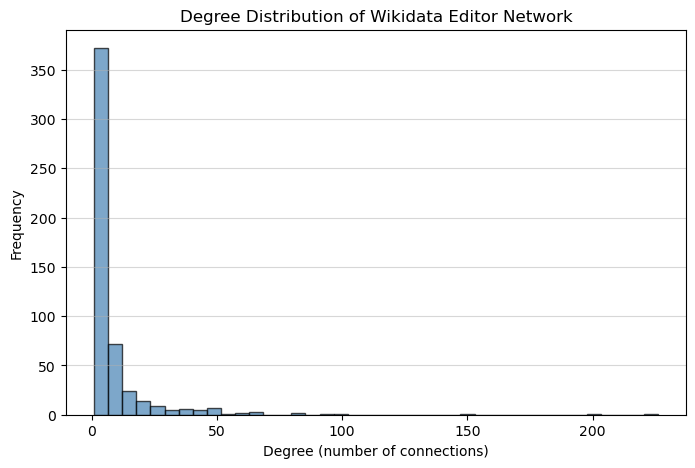


=== Task C: Epidemic Monitoring ===
Randomly selected editors: Nikki and Scarey1

--- Scenario 1: Both editors are 'trolling' ---
Shortest path length between them: 3
Number of common neighbors: 0
Conclusion: They are close or share common neighbors → High risk of local spread.

--- Scenario 2: Only editor A is 'trolling' ---
Immediate neighbors of A: 53
Two-hop neighbors of A: 406
→ Priority should be given to immediate neighbors, then two-hop neighbors.

--- Priority list for checking other editors (if both abnormal) ---
Top 5 editors to check first (by exposure and degree):
          Node  Exposure  Degree
       Pasleim         1     226
         Jura1         1     198
Matěj Suchánek         1     152
      ValterVB         1      98
 Pigsonthewing         1      95

Medium network: PROJECT_CHAT.csv

=== Task A: Network Construction ===
Dataset: PROJECT_CHAT.csv
Number of nodes (editors): 3941
Number of edges (conversations): 40255

1. Nodes and edges representation:
   - Nodes: 

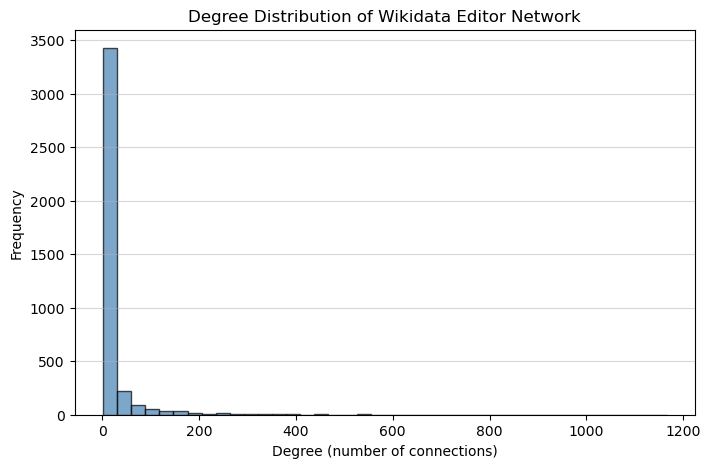


=== Task C: Epidemic Monitoring ===
Randomly selected editors: Antoni1626 and Jaydiem

--- Scenario 1: Both editors are 'trolling' ---
Shortest path length between them: 3
Number of common neighbors: 0
Conclusion: They are close or share common neighbors → High risk of local spread.

--- Scenario 2: Only editor A is 'trolling' ---
Immediate neighbors of A: 7
Two-hop neighbors of A: 1596
→ Priority should be given to immediate neighbors, then two-hop neighbors.

--- Priority list for checking other editors (if both abnormal) ---
Top 5 editors to check first (by exposure and degree):
        Node  Exposure  Degree
 ChristianKl         1     835
ArthurPSmith         1     642
 Tagishsimon         1     580
      TomT0m         1     555
  Multichill         1     477

Large network: REQUEST_FOR_DELETION.csv

=== Task A: Network Construction ===
Dataset: REQUEST_FOR_DELETION.csv
Number of nodes (editors): 9887
Number of edges (conversations): 33488

1. Nodes and edges representation:
   -

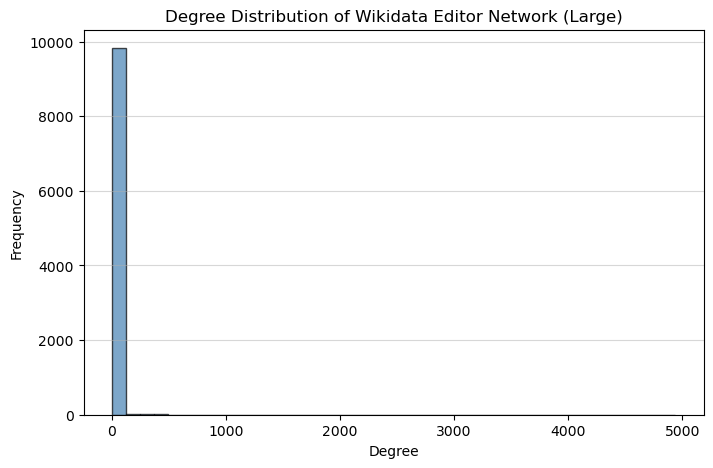


=== Task C: Epidemic Monitoring ===
Randomly selected editors: Poppytarts and KaMan

--- Scenario 1: Both editors are 'trolling' ---
Shortest path length between them: 2
Number of common neighbors: 1
Conclusion: They are close or share common neighbors → High risk of local spread.

--- Scenario 2: Only editor A is 'trolling' ---
Immediate neighbors of A: 2
Two-hop neighbors of A: 4989
→ Priority should be given to immediate neighbors, then two-hop neighbors.

--- Priority list for checking other editors (if both abnormal) ---
Top 5 editors to check first (by exposure and degree):
         Node  Exposure  Degree
     DeltaBot         2    4939
         Cycn         1    1208
MisterSynergy         1     712
        Jura1         1     498
    Wolverène         1     439


In [6]:
# Epidemic Propagation Monitoring Function (Task C)
def simulate_epidemic_monitoring(G):
    """Simulates controversial topic propagation and generates prioritized moderation lists."""
    print("\n=== Task C: Epidemic Monitoring ===")

    # Structural Isolation: Focus analysis exclusively on the global LCC
    LCC_nodes = max(nx.connected_components(G), key=len)
    G_LCC = G.subgraph(LCC_nodes)

    # Initialization: Randomly select two potentially anomalous nodes (editors)
    node_A, node_B = random.sample(list(G_LCC.nodes()), 2)
    print(f"Randomly selected editors: {node_A} and {node_B}")

    # Scenario 1 Assessment: Evaluate topological proximity when both nodes exhibit anomalous behavior
    print("\n--- Scenario 1: Both editors are 'trolling' ---")
    try:
        shortest_path = nx.shortest_path_length(G_LCC, source=node_A, target=node_B)
    except nx.NetworkXNoPath:
        shortest_path = float('inf')
    common_neighbors = list(nx.common_neighbors(G_LCC, node_A, node_B))
    print(f"Shortest path length between them: {shortest_path}")
    print(f"Number of common neighbors: {len(common_neighbors)}")
    if shortest_path > 3 and len(common_neighbors) == 0:
        print("Conclusion: They are far apart and share no common neighbors → Low risk of immediate spread.")
    else:
        print("Conclusion: They are close or share common neighbors → High risk of local spread.")

    # Scenario 2 Assessment: Identify 1-hop and 2-hop susceptibility zones for a single infected node
    print("\n--- Scenario 2: Only editor A is 'trolling' ---")
    neighbors_A = set(G_LCC.neighbors(node_A))
    two_hop_neighbors = set()
    for n in neighbors_A:
        two_hop_neighbors.update(G_LCC.neighbors(n))
    two_hop_neighbors -= neighbors_A
    two_hop_neighbors -= {node_A}
    print(f"Immediate neighbors of A: {len(neighbors_A)}")
    print(f"Two-hop neighbors of A: {len(two_hop_neighbors)}")
    if len(neighbors_A) > 0:
        print("→ Priority should be given to immediate neighbors, then two-hop neighbors.")
    else:
        print("→ No immediate neighbors, so spread is unlikely.")

    # Moderation Prioritization: Extract all susceptible neighbors connected to the infected seeds
    print("\n--- Priority list for checking other editors (if both abnormal) ---")
    infected = {node_A, node_B}
    susceptible = set()
    for seed in infected:
        susceptible.update(G_LCC.neighbors(seed))
    susceptible -= infected

    # Algorithmic Ranking: Sort susceptible nodes by direct exposure, followed by degree centrality
    priority = []
    for n in susceptible:
        exposure = sum(1 for s in infected if G_LCC.has_edge(n, s))
        degree = G_LCC.degree(n)
        priority.append({'Node': n, 'Exposure': exposure, 'Degree': degree})
        
    priority.sort(key=lambda x: (x['Exposure'], x['Degree']), reverse=True)
    
    if priority:
        print("Top 5 editors to check first (by exposure and degree):")
        df = pd.DataFrame(priority).head(5)
        print(df.to_string(index=False))
    else:
        print("No susceptible neighbors found.")

# Execution Pipeline: Apply analytical functions across three distinct network scales
# Small network execution
print("\n" + "="*50)
print("Small network: BOT_REQUESTS.csv")
G_small = build_wikidata_network("BOT_REQUESTS.csv")
analyze_network_metrics(G_small)
simulate_epidemic_monitoring(G_small)

# Medium network execution
print("\n" + "="*50)
print("Medium network: PROJECT_CHAT.csv")
G_medium = build_wikidata_network("PROJECT_CHAT.csv")
analyze_network_metrics(G_medium)
simulate_epidemic_monitoring(G_medium)

# Large network execution (utilizing approximation methodology)
print("\n" + "="*50)
print("Large network: REQUEST_FOR_DELETION.csv")
G_large = build_wikidata_network("REQUEST_FOR_DELETION.csv")
analyze_large_network_approx(G_large, sample_size=100)
simulate_epidemic_monitoring(G_large)

### Final Discussion: Network Comparisons and the Impact of Representation

**Comparative Analysis and Network Continuum**

When comparing the three Wikidata networks, all of them display clear small-world characteristics rather than being purely regular or random networks. Even as the network size grows significantly from 527 nodes to 9,887 nodes, the average shortest path length (L) remains very stable at around 2.6 to 2.7. This is much shorter than what we would expect in a random Erdos-Renyi graph of the same size. However, there is a clear difference in their local clustering. The small and medium networks are highly clustered (C ≈ 0.69 and 0.70), showing that editors in these groups form tight-knit local communities. In contrast, the large network's clustering coefficient drops to 0.39. This suggests that while core "hub" editors keep the whole network connected, the larger dataset (deletion requests) likely includes more one-time or casual participants. As a result, the large network's structure is pushed slightly closer to a random network compared to the smaller, highly cohesive ones.

**The Impact of Network Representation Choices**

It is also important to note that the way the network was built strongly affects these quantitative results. By using a co-occurrence projection, where an undirected edge connects any two editors who commented on the same thread, the original bipartite data structure (users and discussion threads) was transformed into a unipartite graph. This specific modeling approach assumes that everyone in a thread interacts with everyone else, which naturally generates fully connected cliques for every single discussion. Because of this, the global clustering coefficient (C) is artificially inflated, making the network appear more regular and "small-world" than it might actually be. If the network had been built using a more strict, directed reply-tree (connecting only users who directly reply to one another), the number of local triangles would drop significantly. Under that representation, the community might appear more fragmented, and the network would likely shift further away from a regular structure and closer to a scale-free random topology.